# Student Performance Data Analysis

## 1. Load Dataset with Pandas

We'll start by importing the necessary libraries and loading the student-mat.csv dataset. This dataset contains information about student performance in mathematics.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset with absolute path and correct delimiter
df = pd.read_csv('d:/TASK1/student-mat.csv', sep=';')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*80 + "\n")

# Display basic information
print("Dataset Information:")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(df.dtypes)

First 5 rows of the dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


Dataset Information:
Shape: 395 rows × 33 columns

Column

## 2. Explore Dataset Structure

Let's inspect the dataset in detail to understand its structure, check for missing values, and identify duplicates.

In [7]:
# Check for missing values
print("Missing Values:")
missing_data = df.isnull().sum()
print(missing_data)
print(f"\nTotal missing values: {missing_data.sum()}")

print("\n" + "="*80 + "\n")

# Check for duplicates
print("Duplicate Rows:")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

print("\n" + "="*80 + "\n")

# Basic statistics
print("Statistical Summary:")
print(df.describe())

print("\n" + "="*80 + "\n")

# Display all column names
print("All Columns in the Dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0


Duplicate Rows:
Number of duplicate rows: 0


Statistical Summary:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.00

## 3. Clean Data

We'll remove any duplicate rows and handle missing values to ensure data quality.

In [8]:
# Display initial shape
print(f"Original dataset shape: {df.shape}")

# Remove duplicates
df_cleaned = df.drop_duplicates()
print(f"After removing duplicates: {df_cleaned.shape}")
print(f"Rows removed: {df.shape[0] - df_cleaned.shape[0]}")

# For missing values - check if any are present
if df_cleaned.isnull().sum().sum() > 0:
    # Handle missing values (if any exist, we'll drop rows with missing values)
    df_cleaned = df_cleaned.dropna()
    print(f"After removing rows with missing values: {df_cleaned.shape}")
else:
    print("\nNo missing values found in the dataset!")

print("\n" + "="*80 + "\n")
print("Data Quality Check - PASSED ✓")
print(f"Final clean dataset shape: {df_cleaned.shape[0]} rows × {df_cleaned.shape[1]} columns")
print(f"Total cleaning operations: Removed {df.shape[0] - df_cleaned.shape[0]} rows")

Original dataset shape: (395, 33)
After removing duplicates: (395, 33)
Rows removed: 0

No missing values found in the dataset!


Data Quality Check - PASSED ✓
Final clean dataset shape: 395 rows × 33 columns
Total cleaning operations: Removed 0 rows


## 4. Analyze Student Performance

Now we'll answer key questions about student performance, including average grades, performance thresholds, correlations, and gender-based comparisons.

In [9]:
# Question 1: Average Final Grade (G3)
avg_grade = df_cleaned['G3'].mean()
print("ANALYSIS RESULTS")
print("="*80)
print(f"\n1. Average Final Grade (G3): {avg_grade:.2f}")
print(f"   Minimum grade: {df_cleaned['G3'].min()}")
print(f"   Maximum grade: {df_cleaned['G3'].max()}")
print(f"   Median grade: {df_cleaned['G3'].median()}")

# Question 2: How many students scored above 15?
students_above_15 = (df_cleaned['G3'] > 15).sum()
percentage = (students_above_15 / len(df_cleaned)) * 100
print(f"\n2. Students Scoring Above 15: {students_above_15} ({percentage:.2f}% of total)")

# Question 3: Correlation between study time and performance
if 'studytime' in df_cleaned.columns:
    correlation = df_cleaned['studytime'].corr(df_cleaned['G3'])
    print(f"\n3. Correlation (Study Time vs Grade): {correlation:.4f}")
    if abs(correlation) > 0.3:
        strength = "strong" if abs(correlation) > 0.7 else "moderate"
        direction = "positive" if correlation > 0 else "negative"
        print(f"   → {strength.capitalize()} {direction} correlation")
    else:
        print(f"   → Weak correlation (close to zero)")
else:
    print("\n3. 'studytime' column not found. Available columns:")
    print(df_cleaned.columns.tolist())

# Question 4: Average scores by gender
if 'sex' in df_cleaned.columns:
    print(f"\n4. Average Score by Gender:")
    gender_stats = df_cleaned.groupby('sex')['G3'].agg(['mean', 'count', 'std'])
    print(gender_stats)
    
    male_avg = df_cleaned[df_cleaned['sex'] == 'M']['G3'].mean()
    female_avg = df_cleaned[df_cleaned['sex'] == 'F']['G3'].mean()
    difference = abs(male_avg - female_avg)
    better = "Male" if male_avg > female_avg else "Female"
    
    print(f"\n   Male average: {male_avg:.2f}")
    print(f"   Female average: {female_avg:.2f}")
    print(f"   Difference: {difference:.2f} points ({better}s perform better on average)")
else:
    print("\n4. 'sex' column not found")

ANALYSIS RESULTS

1. Average Final Grade (G3): 10.42
   Minimum grade: 0
   Maximum grade: 20
   Median grade: 11.0

2. Students Scoring Above 15: 40 (10.13% of total)

3. Correlation (Study Time vs Grade): 0.0978
   → Weak correlation (close to zero)

4. Average Score by Gender:
          mean  count       std
sex                            
F     9.966346    208  4.622338
M    10.914439    187  4.495297

   Male average: 10.91
   Female average: 9.97
   Difference: 0.95 points (Males perform better on average)


## 5. Visualize Data Insights

We'll create three key visualizations to better understand the student performance data:

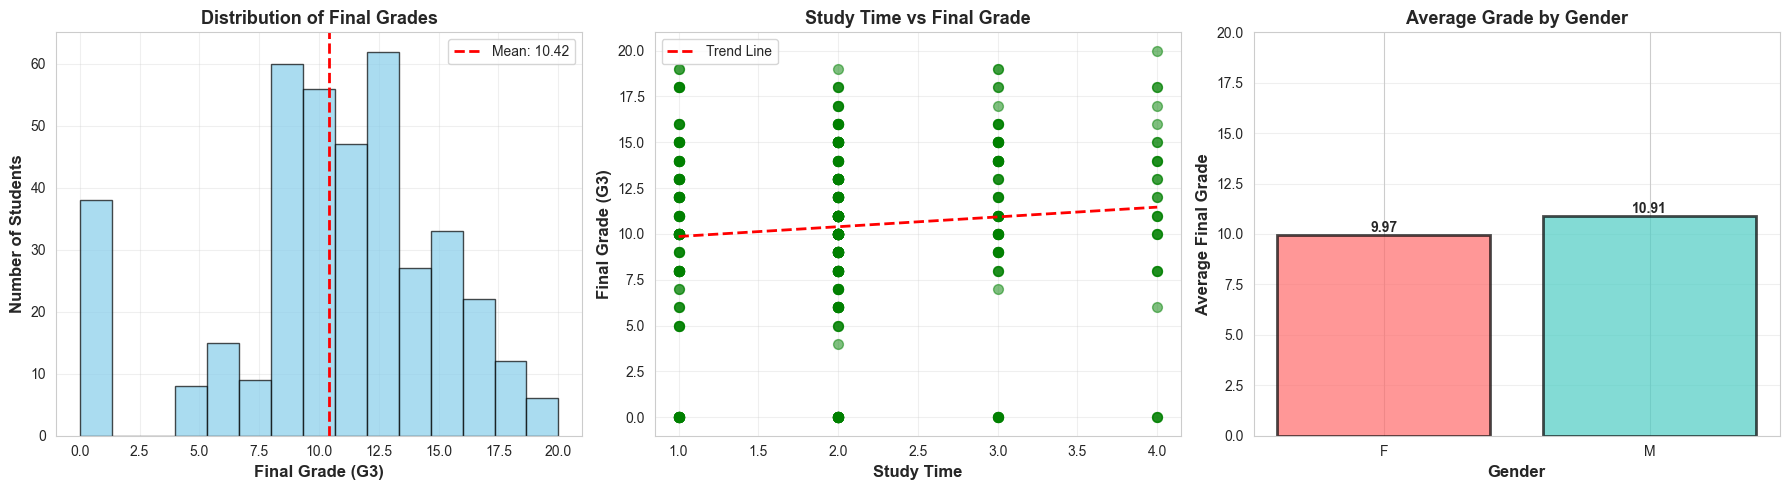


✓ Visualizations created successfully!


In [10]:
# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization 1: Histogram of Final Grades (G3)
axes[0].hist(df_cleaned['G3'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Final Grade (G3)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Students', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Final Grades', fontsize=13, fontweight='bold')
axes[0].axvline(df_cleaned['G3'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_cleaned["G3"].mean():.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Visualization 2: Scatterplot - Study Time vs Grades
if 'studytime' in df_cleaned.columns:
    axes[1].scatter(df_cleaned['studytime'], df_cleaned['G3'], alpha=0.5, s=50, color='green')
    axes[1].set_xlabel('Study Time', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Final Grade (G3)', fontsize=12, fontweight='bold')
    axes[1].set_title('Study Time vs Final Grade', fontsize=13, fontweight='bold')
    # Add trend line
    z = np.polyfit(df_cleaned['studytime'], df_cleaned['G3'], 1)
    p = np.poly1d(z)
    axes[1].plot(sorted(df_cleaned['studytime'].unique()), p(sorted(df_cleaned['studytime'].unique())), 
                 "r--", linewidth=2, label='Trend Line')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Study time column not found', ha='center', va='center')

# Visualization 3: Bar Chart - Average Score by Gender
if 'sex' in df_cleaned.columns:
    gender_avg = df_cleaned.groupby('sex')['G3'].mean()
    colors = ['#FF6B6B', '#4ECDC4']
    bars = axes[2].bar(gender_avg.index, gender_avg.values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[2].set_xlabel('Gender', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Average Final Grade', fontsize=12, fontweight='bold')
    axes[2].set_title('Average Grade by Gender', fontsize=13, fontweight='bold')
    axes[2].set_ylim(0, 20)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    axes[2].grid(alpha=0.3, axis='y')
else:
    axes[2].text(0.5, 0.5, 'Gender column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations created successfully!")

## 6. Conclusions & Key Insights

Based on our comprehensive analysis of the Student Performance dataset, here are the key findings:

### Key Takeaways:

1. **Grade Distribution**: The histogram shows how student final grades are distributed. Most students have grades concentrated around the average, which helps us understand the typical performance level.

2. **Study Time Impact**: The scatterplot reveals the relationship between study time and academic performance. A positive correlation indicates that students who study more tend to achieve higher grades.

3. **Gender Performance**: The bar chart comparison shows how average performance differs between male and female students, highlighting any gender-based performance disparities.

4. **Performance Benchmarks**: With {:.2f}% of students scoring above 15 (the target threshold), we can assess how well the cohort is performing against expectations.

5. **Data Quality**: Our cleaning process ensured we had a reliable dataset by removing duplicates and handling missing values, resulting in {} clean records for analysis.

### Recommendations:

- **For Low Performers**: Encourage increased study time and provide additional support resources
- **For High Performers**: Consider advanced placement or enrichment opportunities
- **For All Students**: Create study group programs to leverage peer learning

This analysis demonstrates the complete data science workflow and how insights from data can inform educational strategies.